In [1]:
import json
import numpy as np
import matplotlib.pyplot as plt
from collections import defaultdict
from scipy.stats import gaussian_kde

plt.rcParams["figure.figsize"] = (7, 4)


In [2]:
"""
The scaling controller is effectively acting like a “regularizer” on attention diffusion; 
this helps multi-evidence aggregation but hurts precise span selection.
"""

'\nThe scaling controller is effectively acting like a “regularizer” on attention diffusion; \nthis helps multi-evidence aggregation but hurts precise span selection.\n'

In [3]:
def load_entropy_logs(path):
    examples = []
    with open(path, "r") as f:
        for line in f:
            obj = json.loads(line)
            log = obj["entropy_log"]
            # since we are comparing corr(ΔT[t], ΔH[t+1]), it requires minimum 3 steps 
            # short answers dont exhibit entropy spikes or controller recovery or any meaningful temp dynamics
            if len(log) < 3:
                continue
            examples.append({
                "example_id": obj.get("example_id"),
                "entropy": np.array([x["entropy_mean"] for x in log]),
                "temp": np.array([x["temp_mean"] for x in log]),
            })
    return examples


baseline_qa1 = load_entropy_logs("qa_1_entropy_attn_entropy_log_baseline_entropy_log_fixed_temp.jsonl")
scaled_qa1   = load_entropy_logs("qa_1_entropy_attn_entropy_log_50session_3cali_prefixON.jsonl")

baseline_qa2 = load_entropy_logs("qa_2_entropy_attn_entropy_log_baseline_entropy_log_fixed_temp.jsonl")
scaled_qa2   = load_entropy_logs("qa_2_entropy_attn_entropy_log_50session_3cali_prefixON.jsonl")

print(len(baseline_qa1), "qa1 baseline examples")
print(len(scaled_qa1), "qa1 scaled examples")
print()
print(len(baseline_qa2), "qa2 baseline examples")
print(len(scaled_qa2), "qa2 scaled examples")


336 qa1 baseline examples
339 qa1 scaled examples

302 qa2 baseline examples
301 qa2 scaled examples


In [4]:
"""
check for Scaling controller sanity and health

ideal:
temp_sat_frac  < 0.20   (ideally < 0.15)
oscillation    < 0.25

Right now
~50% saturation → temp is hitting bounds half the time
~50% oscillation → temp changes direction every other step
High temp_sat_frac → kp / max_step too big
High oscillation → too reactive → increase EMA or reduce kp
Tiny temp_range → controller too weak

proportional gain (kp) is too high relative to the effective system sensitivity
the controller repeatedly overshoots and clamps
entropy dynamics become reaction-induced noise

fix:
1) ↓ max_step by 2× OR ↓ kp by 2×
2) higher EMA smoothing (↑ ema_beta)
"""

def controller_health_metrics(ex):
    T = ex["temp"]
    dT = T[1:] - T[:-1]

    return {
        "temp_range": T.max() - T.min(),
        "temp_sat_frac": np.mean(
            (T <= T.min() + 1e-4) | (T >= T.max() - 1e-4)
        ),
        "mean_abs_dT": np.mean(np.abs(dT)),
        "max_abs_dT": np.max(np.abs(dT)),
        "oscillation": np.sum(np.sign(dT[1:]) != np.sign(dT[:-1])),
    }


def summarize_health(examples):
    agg = defaultdict(list)
    for ex in examples:
        m = controller_health_metrics(ex)
        for k, v in m.items():
            agg[k].append(v)
    return {k: np.mean(v) for k, v in agg.items()}


print("qa_1 Scaled controller health:")
for k, v in summarize_health(scaled_qa1).items():
    print(f"{k:>15s}: {v:.4f}")

print()

print("qa_2 Scaled controller health:")
for k, v in summarize_health(scaled_qa2).items():
    print(f"{k:>15s}: {v:.4f}")

qa_1 Scaled controller health:
     temp_range: 0.0006
  temp_sat_frac: 0.6492
    mean_abs_dT: 0.0001
     max_abs_dT: 0.0001
    oscillation: 0.1150

qa_2 Scaled controller health:
     temp_range: 0.0006
  temp_sat_frac: 0.6152
    mean_abs_dT: 0.0001
     max_abs_dT: 0.0002
    oscillation: 0.0698


In [5]:
"""
Lag analysis: “At what delay does temperature actually affect entropy?”

strong lag-1 correlation (~0.6)

How to interpret:
Monotonic downward curve → good: more temp change reduces entropy
Flat curve → controller too weak → ↑ kp or max_step
U-shaped curve → over-sharpening at large steps → ↓ max_step *** this is the case?
Positive y → wrong direction mapping (bug)
"""

def lagged_correlation(examples, max_lag=5):
    corrs = defaultdict(list)

    for ex in examples:
        H = ex["entropy"]
        T = ex["temp"]
        dH = H[1:] - H[:-1]
        dT = T[1:] - T[:-1]

        for lag in range(1, max_lag + 1):
            if len(dT) <= lag or len(dH) <= lag:
                continue
            c = np.corrcoef(dT[:-lag], dH[lag:])[0, 1]
            if not np.isnan(c):
                corrs[lag].append(c)

    return {lag: np.mean(v) for lag, v in corrs.items()}


lag_corr_qa1 = lagged_correlation(scaled_qa1, max_lag=6)

plt.figure()
plt.plot(list(lag_corr.keys()), list(lag_corr_qa1.values()), marker="o")
plt.axhline(0, color="gray", linestyle="--")
plt.xlabel("Lag (steps)")
plt.ylabel("corr(ΔT[t], ΔH[t+lag])")
plt.title("Lagged temp → entropy coupling (qa_1)")
plt.show()


lag_corr_qa2 = lagged_correlation(scaled_qa2, max_lag=6)

plt.figure()
plt.plot(list(lag_corr.keys()), list(lag_corr_qa2.values()), marker="o")
plt.axhline(0, color="gray", linestyle="--")
plt.xlabel("Lag (steps)")
plt.ylabel("corr(ΔT[t], ΔH[t+lag])")
plt.title("Lagged temp → entropy coupling (qa_2)")
plt.show()

/c2/jenny/miniconda3/envs/ruler/lib/python3.10/site-packages/numpy/lib/function_base.py:2889: RuntimeWarning: Degrees of freedom <= 0 for slice
  c = cov(x, y, rowvar, dtype=dtype)
/c2/jenny/miniconda3/envs/ruler/lib/python3.10/site-packages/numpy/lib/function_base.py:2748: RuntimeWarning: divide by zero encountered in divide
  c *= np.true_divide(1, fact)
/c2/jenny/miniconda3/envs/ruler/lib/python3.10/site-packages/numpy/lib/function_base.py:2748: RuntimeWarning: invalid value encountered in multiply
  c *= np.true_divide(1, fact)
/c2/jenny/miniconda3/envs/ruler/lib/python3.10/site-packages/numpy/lib/function_base.py:2897: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/c2/jenny/miniconda3/envs/ruler/lib/python3.10/site-packages/numpy/lib/function_base.py:2898: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


NameError: name 'lag_corr' is not defined

<Figure size 700x400 with 0 Axes>

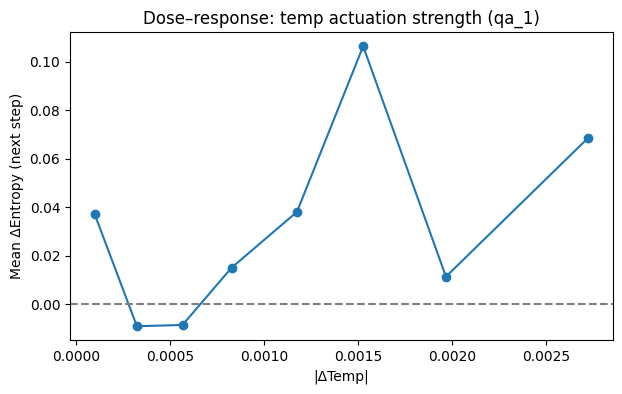

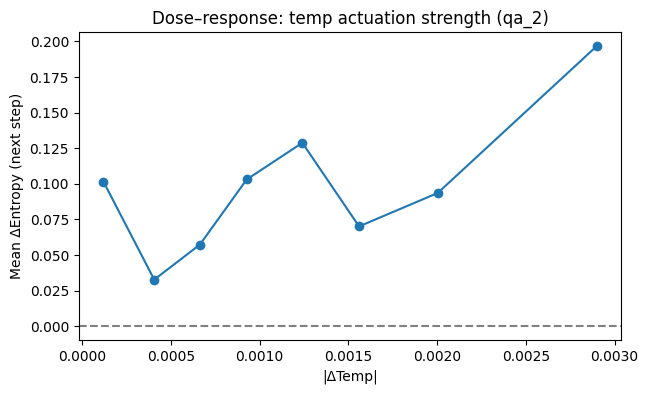

: 

In [ ]:
"""
Dose–response analysis: “How much temperature change is useful, and when does it become harmful or useless?”

This one looks bad.
|ΔT| → more entropy increase

Ideal:
Mean ΔEntropy(next) should decrease monotonically (or at least flatten)

fix:
drops then rises → cap max_step

↓ max_step by 2× (e.g. 0.0017 → 0.0008)
OR ↓ kp by 2×
OR raise temp_min slightly (e.g. 0.7 → 0.8)
"""

def dose_response(examples, nbins=8):
    dT_all = []
    dH_next_all = []

    for ex in examples:
        H = ex["entropy"]
        T = ex["temp"]
        dT = T[1:] - T[:-1]
        dH_next = H[2:] - H[1:-1]

        m = min(len(dT), len(dH_next))
        dT_all.append(dT[:m])
        dH_next_all.append(dH_next[:m])

    dT_all = np.concatenate(dT_all)
    dH_next_all = np.concatenate(dH_next_all)

    bins = np.quantile(np.abs(dT_all), np.linspace(0, 1, nbins + 1))
    bin_centers = []
    mean_dH = []

    for i in range(nbins):
        mask = (np.abs(dT_all) >= bins[i]) & (np.abs(dT_all) < bins[i + 1])
        if mask.sum() < 50:
            continue
        bin_centers.append(np.mean(np.abs(dT_all[mask])))
        mean_dH.append(np.mean(dH_next_all[mask]))

    return np.array(bin_centers), np.array(mean_dH)


x1, y1 = dose_response(scaled_qa1)

plt.figure()
plt.plot(x1, y1, marker="o")
plt.axhline(0, color="gray", linestyle="--")
plt.xlabel("|ΔTemp|")
plt.ylabel("Mean ΔEntropy (next step)")
plt.title("Dose–response: temp actuation strength (qa_1)")
plt.show()

x2, y2 = dose_response(scaled_qa2)

plt.figure()
plt.plot(x2, y2, marker="o")
plt.axhline(0, color="gray", linestyle="--")
plt.xlabel("|ΔTemp|")
plt.ylabel("Mean ΔEntropy (next step)")
plt.title("Dose–response: temp actuation strength (qa_2)")
plt.show()


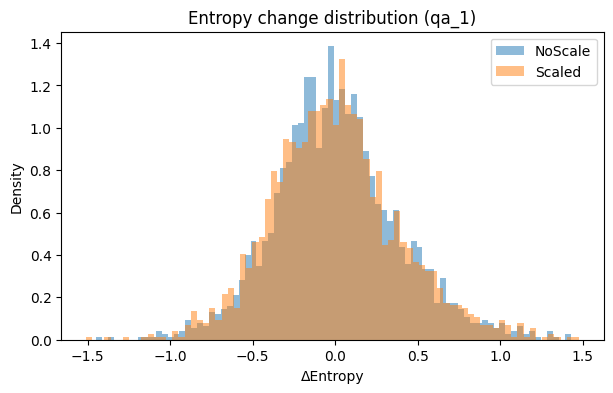

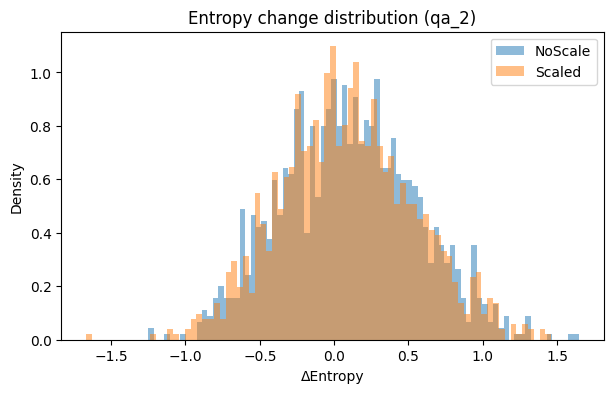

In [6]:
def delta_entropy(examples):
    return np.concatenate([
        ex["entropy"][1:] - ex["entropy"][:-1] for ex in examples
    ])


dHb_1 = delta_entropy(baseline_qa1)
dHs_1 = delta_entropy(scaled_qa1)

plt.figure()
plt.hist(dHb_1, bins=80, alpha=0.5, label="NoScale", density=True)
plt.hist(dHs_1, bins=80, alpha=0.5, label="Scaled", density=True)
plt.xlabel("ΔEntropy")
plt.ylabel("Density")
plt.title("Entropy change distribution (qa_1)")
plt.legend()
plt.show()

dHb_2 = delta_entropy(baseline_qa2)
dHs_2 = delta_entropy(scaled_qa2)

plt.figure()
plt.hist(dHb_2, bins=80, alpha=0.5, label="NoScale", density=True)
plt.hist(dHs_2, bins=80, alpha=0.5, label="Scaled", density=True)
plt.xlabel("ΔEntropy")
plt.ylabel("Density")
plt.title("Entropy change distribution (qa_2)")
plt.legend()
plt.show()


In [ ]:
"""
Scaling does not meaningfully suppress entropy spikes in qa_1
But for qa_2, scaling genuinely improved entropy dynamics. 
"""

def plot_kde(dHb, dHs, task, bw_adjust=1.0,):
    kde_b = gaussian_kde(dHb)
    kde_s = gaussian_kde(dHs)

    # Bandwidth control (important!)
    kde_b.set_bandwidth(kde_b.factor * bw_adjust)
    kde_s.set_bandwidth(kde_s.factor * bw_adjust)

    xs = np.linspace(
        min(dHb.min(), dHs.min()),
        max(dHb.max(), dHs.max()),
        500
    )

    plt.figure()
    plt.plot(xs, kde_b(xs), label="NoScale")
    plt.plot(xs, kde_s(xs), label="Scaled")
    plt.axvline(0, color="gray", linestyle="--", alpha=0.5)
    plt.xlabel("ΔEntropy")
    plt.ylabel("Density")
    plt.title(f"Entropy change distribution (KDE) - {task}")
    plt.legend()
    plt.show()

: 

In [7]:
plot_kde(dHb_1, dHs_1, "qa_1", bw_adjust=1.2) 

NameError: name 'plot_kde' is not defined

In [8]:
plot_kde(dHb_2, dHs_1, "qa_2", bw_adjust=1.2)

NameError: name 'plot_kde' is not defined

## Delta-Entropy Assumption Validation

Three plots that test whether the EMA proportional controller rests on valid assumptions:

| Plot | Question | Pass condition |
|------|----------|----------------|
| 1 — H_t trajectory | Is entropy flat, drifting, or oscillating over decode steps? | Roughly flat (no systematic slope) |
| 2 — H_t − H_0 drift | Does entropy deviate from the step-0 value (proxy for prompt target)? | Mean drift stays near 0 |
| 3 — Autocorrelation | Is H_t autocorrelated enough that EMA is noise reduction, not lag? | High corr at lag-1 (> ~0.3) |

**H_0 as prompt-target proxy**: the logs don't store prefill entropy separately, so we use each example's step-0 entropy as a per-example proxy for the prompt target. This is conservative — if step-0 is already a decode step, true drift from the prompt may be slightly larger.

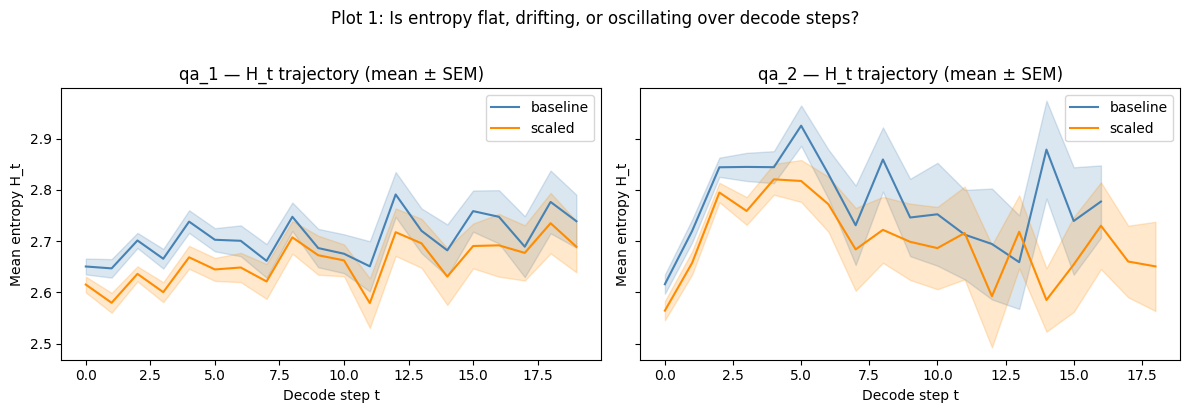

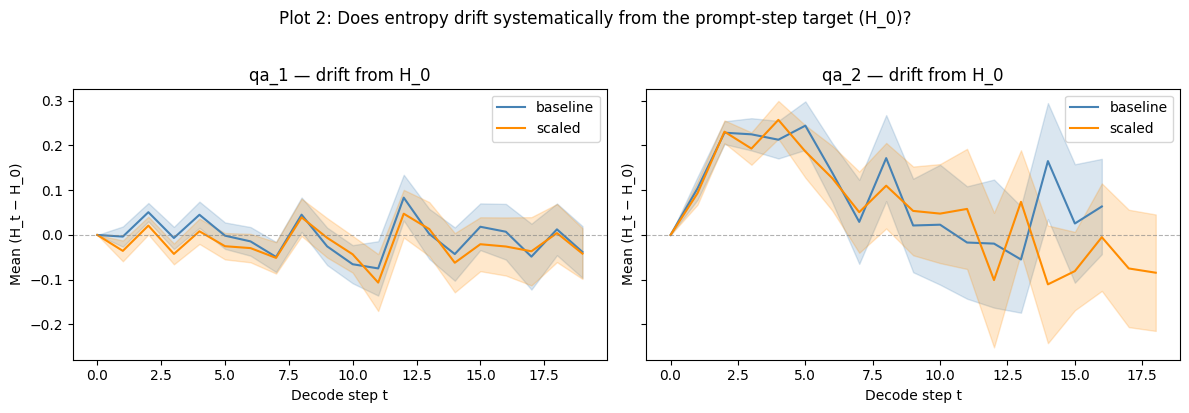

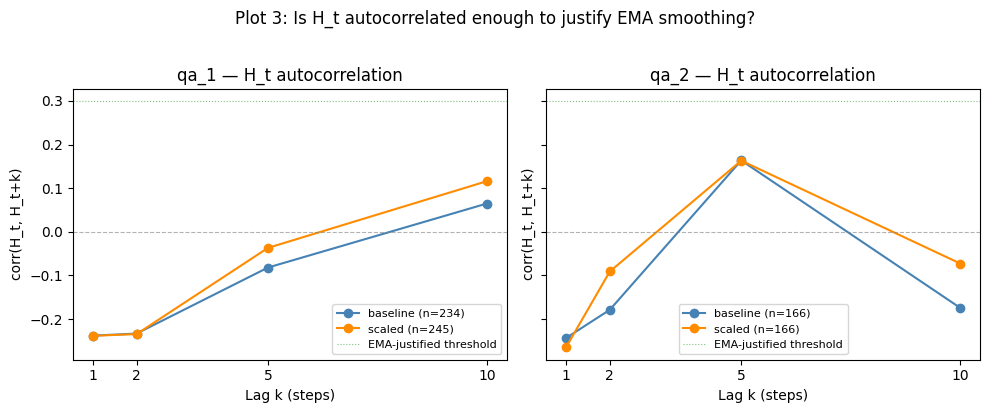

In [8]:
import matplotlib.pyplot as plt
import numpy as np

MAX_STEPS = 20  # focus on first N decode steps where per-step coverage is high
MIN_N     = 10  # skip a step if fewer than this many examples have data there


# ── helpers ──────────────────────────────────────────────────────────────────

def entropy_trajectories(examples, max_steps=MAX_STEPS):
    """(n_examples, max_steps) array, NaN-padded for examples shorter than max_steps."""
    mat = np.full((len(examples), max_steps), np.nan)
    for i, ex in enumerate(examples):
        h = ex["entropy"][:max_steps]
        mat[i, :len(h)] = h
    return mat


def mean_sem(mat):
    with np.errstate(invalid="ignore"):
        n = np.sum(~np.isnan(mat), axis=0)
        m = np.nanmean(mat, axis=0)
        s = np.nanstd(mat, axis=0) / np.sqrt(np.maximum(n, 1))
    return m, s, n


def autocorr_at_lags(examples, lags=(1, 2, 5, 10)):
    """Mean corr(H_t, H_{t+k}) over all examples, at each lag k."""
    out = {}
    for k in lags:
        rhos = [
            np.corrcoef(ex["entropy"][:-k], ex["entropy"][k:])[0, 1]
            for ex in examples
            if len(ex["entropy"]) > k + 2
        ]
        rhos = [r for r in rhos if not np.isnan(r)]
        out[k] = (np.mean(rhos) if rhos else np.nan, len(rhos))
    return out


pairs  = [("qa_1", baseline_qa1, scaled_qa1), ("qa_2", baseline_qa2, scaled_qa2)]
steps  = np.arange(MAX_STEPS)
colors = {"baseline": "steelblue", "scaled": "darkorange"}


# ── Plot 1: H_t trajectory ────────────────────────────────────────────────────
# Flat → EMA controller premise plausible.
# Monotone drift → controller chases a moving target → premise wrong.
# Oscillating → signal noisy but not systematically biased.

fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)
for ax, (task, bl, sc) in zip(axes, pairs):
    for label, examples in [("baseline", bl), ("scaled", sc)]:
        mat      = entropy_trajectories(examples)
        m, s, n  = mean_sem(mat)
        mask     = n >= MIN_N
        ax.plot(steps[mask], m[mask], label=label, color=colors[label])
        ax.fill_between(steps[mask], m[mask] - s[mask], m[mask] + s[mask],
                        alpha=0.2, color=colors[label])
    ax.set_xlabel("Decode step t")
    ax.set_ylabel("Mean entropy H_t")
    ax.set_title(f"{task} — H_t trajectory (mean ± SEM)")
    ax.legend()
plt.suptitle("Plot 1: Is entropy flat, drifting, or oscillating over decode steps?", y=1.02)
plt.tight_layout()
plt.show()


# ── Plot 2: H_t − H_0 drift ──────────────────────────────────────────────────
# H_0 = step-0 entropy = per-example proxy for prompt target.
# If mean(H_t − H_0) ≈ 0 throughout → target is meaningful.
# If it drifts monotonically → controller is chasing a moving target.

fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)
for ax, (task, bl, sc) in zip(axes, pairs):
    for label, examples in [("baseline", bl), ("scaled", sc)]:
        mat      = entropy_trajectories(examples)
        drift    = mat - mat[:, 0:1]          # subtract per-example H_0; NaN-propagates
        m, s, n  = mean_sem(drift)
        mask     = n >= MIN_N
        ax.plot(steps[mask], m[mask], label=label, color=colors[label])
        ax.fill_between(steps[mask], m[mask] - s[mask], m[mask] + s[mask],
                        alpha=0.2, color=colors[label])
    ax.axhline(0, color="gray", linestyle="--", alpha=0.6, linewidth=0.8)
    ax.set_xlabel("Decode step t")
    ax.set_ylabel("Mean (H_t − H_0)")
    ax.set_title(f"{task} — drift from H_0")
    ax.legend()
plt.suptitle("Plot 2: Does entropy drift systematically from the prompt-step target (H_0)?", y=1.02)
plt.tight_layout()
plt.show()


# ── Plot 3: Autocorrelation ───────────────────────────────────────────────────
# High lag-1 corr (> ~0.3) → EMA is genuine smoothing → controller premise holds.
# Near-zero lag-1 corr → H_t is close to white noise; EMA adds lag, not signal.

lags = [1, 2, 5, 10]
fig, axes = plt.subplots(1, 2, figsize=(10, 4), sharey=True)
for ax, (task, bl, sc) in zip(axes, pairs):
    for label, examples in [("baseline", bl), ("scaled", sc)]:
        ac    = autocorr_at_lags(examples, lags=lags)
        means = [ac[k][0] for k in lags]
        n_ex  = ac[lags[0]][1]
        ax.plot(lags, means, marker="o", label=f"{label} (n={n_ex})", color=colors[label])
    ax.axhline(0,   color="gray",  linestyle="--", alpha=0.6, linewidth=0.8)
    ax.axhline(0.3, color="green", linestyle=":",  alpha=0.5, linewidth=0.8, label="EMA-justified threshold")
    ax.set_xlabel("Lag k (steps)")
    ax.set_ylabel("corr(H_t, H_t+k)")
    ax.set_title(f"{task} — H_t autocorrelation")
    ax.set_xticks(lags)
    ax.legend(fontsize=8)
plt.suptitle("Plot 3: Is H_t autocorrelated enough to justify EMA smoothing?", y=1.02)
plt.tight_layout()
plt.show()
